# 05 — Forecasting

Evaluates the selected ARIMA model on the untouched test period, reconstructs predictions on the original closing-price scale, and generates a short-term future forecast.

In [15]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "petr4_features.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "arima_close_diff.pkl"
METADATA_PATH = PROJECT_ROOT / "models" / "arima_metadata.json"
FORECAST_PATH = PROJECT_ROOT / "data" / "processed" / "petr4_forecast.csv"
FUTURE_MODEL_PATH = PROJECT_ROOT / "models" / "arima_full_close.pkl"
FORECAST_HORIZON = 10

required_files = [PROCESSED_PATH, MODEL_PATH, METADATA_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Required artifacts not found: {missing_files}")

df = pd.read_csv(PROCESSED_PATH, parse_dates=["Date"], index_col="Date").sort_index()
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
fitted_model = ARIMAResults.load(MODEL_PATH)

## Test-set evaluation

The saved model was fitted only on training and validation data. Forecasts below therefore represent genuine out-of-sample predictions.

In [16]:
test_start = pd.Timestamp(metadata["test_start"])
test = df.loc[df.index >= test_start, "Close_diff"].dropna()

if test.empty:
    raise ValueError("No observations were found in the test period.")

test_forecast_result = fitted_model.get_forecast(steps=len(test))
predicted_difference = pd.Series(
    test_forecast_result.predicted_mean.to_numpy(),
    index=test.index,
    name="Predicted_Close_diff",
)

difference_metrics = pd.Series({
    "MAE": np.mean(np.abs(test - predicted_difference)),
    "RMSE": np.sqrt(np.mean((test - predicted_difference) ** 2)),
    "Directional accuracy (%)": 100 * np.mean(np.sign(test) == np.sign(predicted_difference)),
})
display(difference_metrics.to_frame("value").round(4))

,value
MAE,0.5218
RMSE,0.7039
Directional accuracy (%),61.2903


The ARIMA model achieved an MAE of 0.5218 and an RMSE of 0.7039 for daily closing-price differences. Both metrics are higher than those obtained during validation, indicating a deterioration in predictive performance on the later, unseen test period.

Directional accuracy reached 61.29%, meaning that the model correctly predicted the direction of the daily price change in approximately six out of ten sessions. This result should be interpreted alongside the observed class distribution and a directional baseline, since an accuracy above 50% does not necessarily imply meaningful predictive ability when upward and downward movements are unbalanced.

## Reconstruct the closing price

Predicted daily differences are cumulatively added to the last closing price observed before the test period. A random-walk forecast, which assumes that the price remains equal to the last observed value, is used as the baseline.

In [17]:
previous_close = df.loc[df.index < test.index[0], "Close"].iloc[-1]
actual_close = df.loc[test.index, "Close"].rename("Actual")
predicted_close = pd.Series(
    previous_close + predicted_difference.cumsum().to_numpy(),
    index=test.index,
    name="ARIMA",
)
naive_close = pd.Series(previous_close, index=test.index, name="Naive")

def price_metrics(actual: pd.Series, predicted: pd.Series) -> dict:
    error = actual.to_numpy() - predicted.to_numpy()
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAPE (%)": float(100 * np.mean(np.abs(error / actual.to_numpy()))),
    }

price_evaluation = pd.DataFrame({
    "ARIMA": price_metrics(actual_close, predicted_close),
    "Naive": price_metrics(actual_close, naive_close),
}).T
display(price_evaluation.round(4))

,MAE,RMSE,MAPE (%)
ARIMA,8.6623,10.6561,20.3187
Naive,8.9595,10.9690,21.0501


After reconstructing the closing-price trajectory, the ARIMA model achieved slightly lower MAE, RMSE, and MAPE than the random-walk baseline. However, the improvement was modest, indicating limited practical gain over the simpler benchmark.

The larger errors on the price scale are partly explained by the multi-step reconstruction procedure. Because the entire test path is generated from a single forecast origin, errors in the predicted daily differences accumulate over time and progressively affect the reconstructed price trajectory.

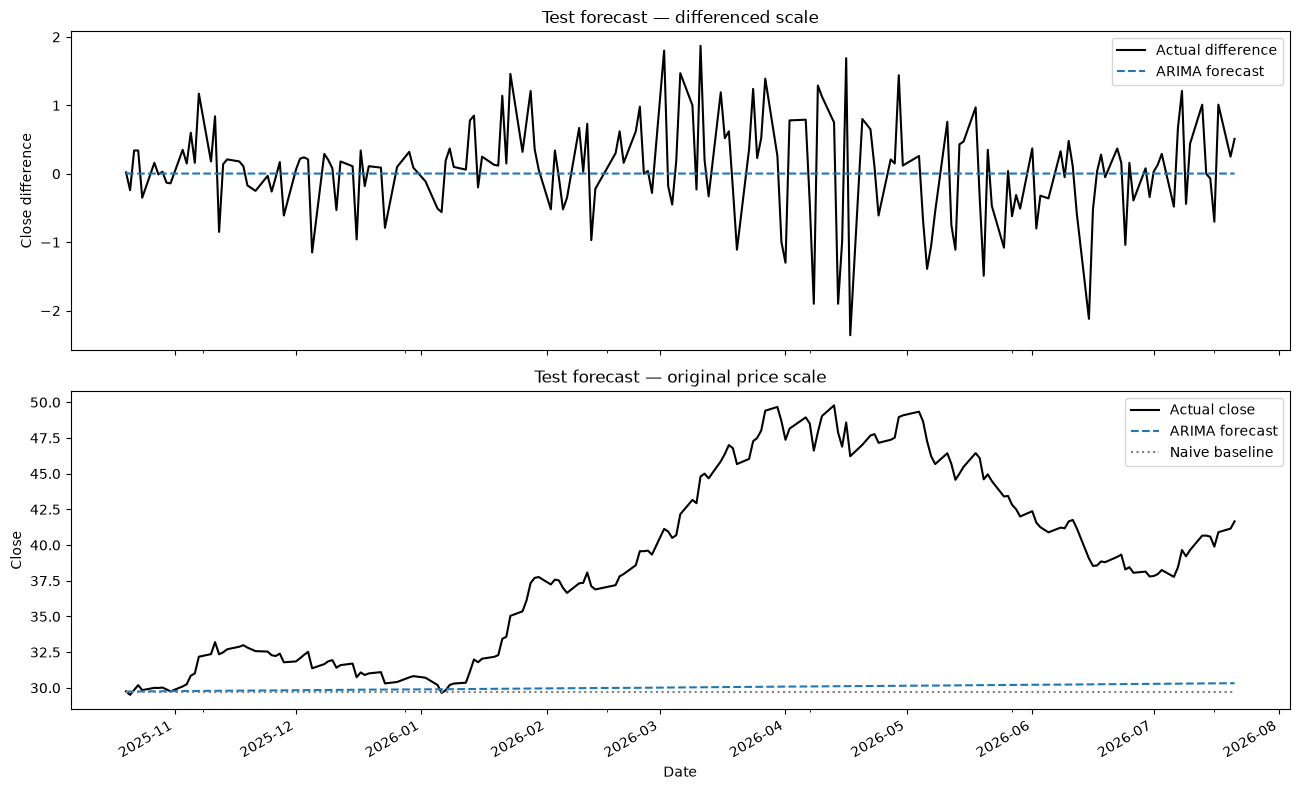

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

test.plot(ax=axes[0], label="Actual difference", color="black")
predicted_difference.plot(ax=axes[0], label="ARIMA forecast", color="tab:blue", linestyle="--")
axes[0].set(title="Test forecast — differenced scale", ylabel="Close difference")
axes[0].legend()

actual_close.plot(ax=axes[1], label="Actual close", color="black")
predicted_close.plot(ax=axes[1], label="ARIMA forecast", color="tab:blue", linestyle="--")
naive_close.plot(ax=axes[1], label="Naive baseline", color="tab:gray", linestyle=":")
axes[1].set(title="Test forecast — original price scale", xlabel="Date", ylabel="Close")
axes[1].legend()

plt.tight_layout()
plt.show()

The ARIMA forecast quickly converges to the mean of the differenced series, which is close to zero. As a result, the reconstructed price remains nearly constant throughout the forecast horizon.

This behavior is expected for a multi-step forecast generated by a low-order ARIMA model. As uncertainty accumulates, the model gradually loses information about future price movements and converges toward its long-run expectation.

Consequently, the ARIMA model provides only a modest improvement over the random-walk baseline during the test period.

## Future forecast

After test evaluation, the selected specification is refitted on all available closing prices as `ARIMA(p,1,q)` with drift. The dates below are business-day approximations and do not account for exchange holidays.

In [19]:
p, _, q = metadata["order"]
level_order = (int(p), 1, int(q))
full_close = df["Close"].dropna().astype(float)
full_close_model = pd.Series(
    full_close.to_numpy(),
    index=pd.RangeIndex(len(full_close)),
    name="Close",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    future_model = ARIMA(full_close_model, order=level_order, trend="t").fit()

future_result = future_model.get_forecast(steps=FORECAST_HORIZON)
future_frame = future_result.summary_frame(alpha=0.05)
future_index = pd.bdate_range(
    start=full_close.index[-1] + pd.offsets.BDay(1),
    periods=FORECAST_HORIZON,
)
future_forecast = pd.DataFrame({
    "forecast": future_frame["mean"].to_numpy(),
    "lower_95": future_frame["mean_ci_lower"].to_numpy(),
    "upper_95": future_frame["mean_ci_upper"].to_numpy(),
}, index=future_index)
future_forecast.index.name = "Date"
display(future_forecast.round(2))

,forecast,lower_95,upper_95
Date,,,
2026-07-22,41.68,40.31,43.06
2026-07-23,41.70,39.73,43.66
2026-07-24,41.71,39.29,44.12
2026-07-27,41.72,38.93,44.51
2026-07-28,41.73,38.61,44.86
2026-07-29,41.74,38.32,45.17
2026-07-30,41.75,38.05,45.46
2026-07-31,41.77,37.81,45.73
2026-08-03,41.78,37.58,45.98


The ten-session forecast remains close to the most recent observed closing price, with only a slight upward drift over the horizon. This behavior is consistent with the weak short-term dependence identified in the differenced series.

The 95% prediction interval widens steadily as the forecast horizon increases, reflecting growing uncertainty about future price movements. Although the point forecast suggests relative stability, the interval indicates that substantially lower or higher prices remain plausible.

These projections should therefore be interpreted as a probabilistic short-term scenario rather than as precise price targets.

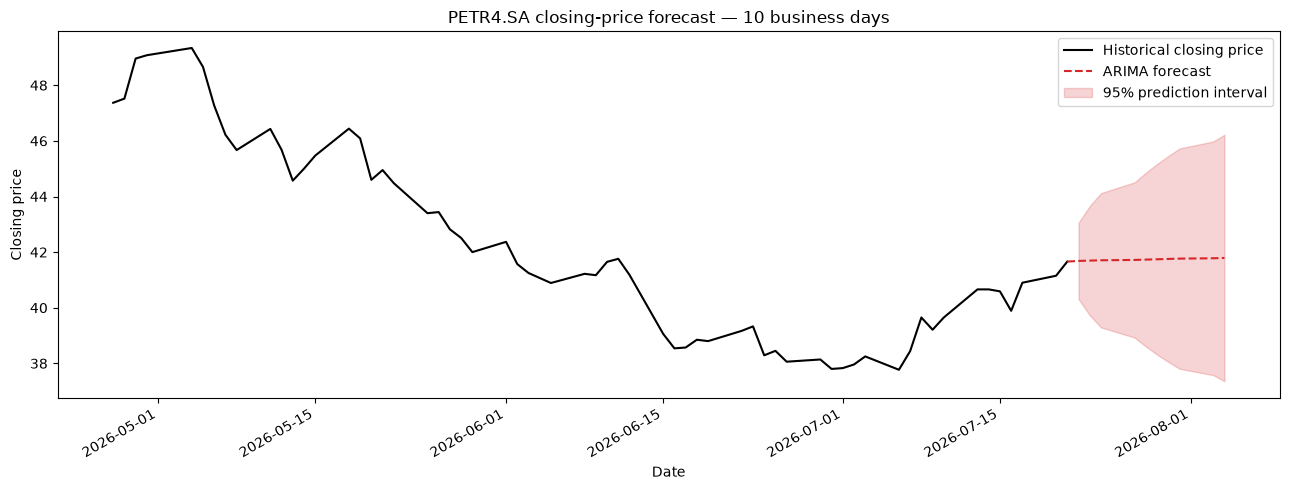

In [26]:
recent_close = full_close.tail(60)

forecast_line = pd.concat([
    full_close.tail(1).rename("Forecast"),
    future_forecast["forecast"],
])

fig, ax = plt.subplots(figsize=(13, 5))

recent_close.plot(
    ax=ax,
    label="Historical closing price",
    color="black",
)

forecast_line.plot(
    ax=ax,
    label="ARIMA forecast",
    color="tab:red",
    linestyle="--",
)

ax.fill_between(
    future_forecast.index,
    future_forecast["lower_95"],
    future_forecast["upper_95"],
    color="tab:red",
    alpha=0.20,
    label="95% prediction interval",
)

ax.set(
    title=f"PETR4.SA closing-price forecast — {FORECAST_HORIZON} business days",
    xlabel="Date",
    ylabel="Closing price",
)

ax.legend(frameon=True)
plt.tight_layout()
plt.show()

The ARIMA model projects a relatively stable closing price over the next ten business days, remaining close to the latest observed market value. This behavior reflects the limited linear dependence identified during model selection, causing the forecast to converge toward the expected level of the series rather than extrapolating recent price movements.

The 95% prediction interval widens as the forecast horizon increases, indicating that uncertainty accumulates over time. Consequently, while the point forecast suggests little short-term variation, the interval highlights that a broad range of future prices remains plausible.

Overall, the forecast should be interpreted as a probabilistic estimate of future prices rather than a precise prediction of the closing price on each trading day.

In [27]:
FORECAST_PATH.parent.mkdir(parents=True, exist_ok=True)
FUTURE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
future_forecast.to_csv(FORECAST_PATH)
future_model.save(FUTURE_MODEL_PATH)

## Overall interpretation

The project analyzed PETR4 daily market data from July 2021 to July 2026 and developed an ARIMA-based forecasting pipeline for the closing price. The exploratory analysis identified a non-stationary price series, substantial variation in trading volume, volatility clustering, and weak linear dependence in daily price changes.

The Augmented Dickey–Fuller test indicated that the closing-price level was non-stationary, while the first difference was stationary. Based on this result, the ARIMA specification was selected using validation-set performance on `Close_diff`, while the final test period remained isolated from model selection.

ARIMA(0, 0, 1) achieved the lowest validation MSE among the evaluated candidates. However, its performance was very close to simpler specifications, indicating limited autoregressive and moving-average structure in the differenced series.

On the untouched test set, the model achieved an MAE of 0.5218, an RMSE of 0.7039, and a directional accuracy of 61.29% for daily price changes. After reconstructing forecasts on the original price scale, the ARIMA model slightly outperformed the naive random-walk baseline, with an MAE of 8.6623, an RMSE of 10.6561, and a MAPE of 20.3187. The improvement over the baseline was modest, suggesting limited practical gain from the selected ARIMA specification.

The future forecast remained close to the latest observed closing price, while the 95% prediction interval widened as the forecast horizon increased. This behavior reflects the accumulation of uncertainty and the model’s limited ability to anticipate abrupt market movements.

Overall, the ARIMA model provides a transparent statistical baseline for PETR4 forecasting, but its predictive capacity is constrained by weak linear dependence, time-varying volatility, and the accumulation of errors in multi-step forecasts. The results should be interpreted as probabilistic estimates rather than precise price targets and do not constitute investment advice.